<div dir="rtl">

# תרגיל 2 — ערן רחני 207823063

השוואת שלוש שיטות אינטרפולציה על טבלה לא-אחידה של $\cos(x)$, בשלוש צפיפויות (101, 51, 26 נקודות).

</div>

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Data initialization
# Build a non-equally-spaced x array: start from integer indices,
# then perturb interior points by a random offset in [-1/3, +1/3] of the nominal spacing.
npoints = 101
xmax = 10.
np.random.seed(12345)          # fix seed for reproducibility (governs both x and x_test)
x = np.arange(npoints, dtype="float64")   # integer indices 0..100
x[npoints-1] = xmax            # force the last point to exactly xmax = 10

# Generate npoints-2 uniform random numbers in [0,1) for perturbation of interior points
r = np.random.rand(npoints-2)
# Scale each interior index to [0, xmax] and add a random offset in [-1/3h, +1/3h]
# where h = xmax/(npoints-1) is the nominal (equal) spacing
x[1:npoints-1] = (x[1:npoints-1] + (r[0:npoints-2]-0.5)/1.5) * xmax/(npoints-1)

# Sample the function we want to interpolate: f(x) = cos(x)
y = np.cos(x)

# Choose 10 random test points inside [0, xmax] to evaluate interpolation accuracy
ntests = 10
x_test = np.random.rand(ntests) * xmax

print("x range: [{:.4f}, {:.4f}]".format(x[0], x[-1]))
print("x_test:", np.round(x_test, 4))

x range: [0.0000, 10.0000]
x_test: [0.4272 1.9579 2.945  6.27   0.8622 1.4295 5.1583 6.8934 8.5663 6.4736]


<div dir="rtl">

## `print_out`

מדפיסה את השגיאה המקסימלית וטבלת $(x,\, y_\text{interp},\, \text{error})$.

</div>

In [10]:
def print_out(xv, yv):
    """Print max absolute error and a table of (x, y_interp, error) for each test point."""
    # Maximum absolute error across all test points
    print('%18s %12.4e' % ('max. error was:', np.amax(np.abs(yv - np.cos(xv)))))
    # Header row
    print('%12s %12s %12s' % ('test_x', 'y_interp', 'error'))
    # Per-point rows: x, interpolated value, and signed error = y_interp - exact
    for i in range(ntests):
        print('%12.4e %12.4e %12.4e' % (xv[i], yv[i], yv[i] - np.cos(xv[i])))
    return

<div dir="rtl">

## שיטות אינטרפולציה

### ליניארית — $O(h^2)$

ישר בין שני קשרים סמוכים $x_i \le x_1 < x_{i+1}$:

</div>

$$y_1 = y_i + (y_{i+1} - y_i)\frac{x_1 - x_i}{x_{i+1} - x_i}$$

<div dir="rtl">

### לגראנז' 4 נקודות — $O(h^4)$

פולינום ממעלה 3 דרך 4 קשרים $x_{i-1},x_i,x_{i+1},x_{i+2}$:

</div>

$$y_1 = \sum_{k=0}^{3} y_{n_k} L_k(x_1), \qquad L_k = \prod_{j \neq k} \frac{x_1 - x_{n_j}}{x_{n_k} - x_{n_j}}$$

<div dir="rtl">

**גבולות:** אם $x_1 \le x[1]$ מחזירים $y[1]$; אם $x_1 \ge x[n-2]$ מחזירים $y[n-2]$.

</div>

<div dir="rtl">

### הרמיט 4 נקודות — $O(h^4)$

קובי שמתאים גם ערכים וגם נגזרות בקצוות הקטע — מבטיח עקומה $C^1$ (ללא פינות).

הנגזרת נאמדת בנוסחת 3 נקודות לא-אחידות:

</div>

$$f'(x_m) = f_a\frac{x_m-x_b}{(x_a-x_m)(x_a-x_b)} + f_m\frac{2x_m-x_a-x_b}{(x_m-x_a)(x_m-x_b)} + f_b\frac{x_m-x_a}{(x_b-x_a)(x_b-x_m)}$$

<div dir="rtl">

עם $h=x_{i+1}-x_i$, $t=(x_1-x_i)/h$:

</div>

$$H = (2t^3-3t^2+1)y_i + (t^3-2t^2+t)hm_i + (-2t^3+3t^2)y_{i+1} + (t^3-t^2)hm_{i+1}$$

In [11]:
def interp(x, y, x1, itype):
    """
    Interpolate y at x1 using the given method.
    x must be a sorted 1-D array; x1 must lie strictly inside [x[0], x[-1]].
    itype: 'Linear', 'Lagrange4', or 'Hermit4'
    """
    n = len(x)

    #Linear 
    if itype == 'Linear':
        i = np.searchsorted(x, x1, side='right') - 1   # x[i] <= x1 < x[i+1]
        i = int(np.clip(i, 0, n - 2))
        return float(y[i] + (y[i+1] - y[i]) * (x1 - x[i]) / (x[i+1] - x[i]))

    # Shared bracket logic for 4-point methods
    i = int(np.searchsorted(x, x1, side='right') - 1)

    # Boundary rule: need 2 nodes on each side
    if x1 <= x[1]:
        return float(y[1])
    if x1 >= x[n - 2]:
        return float(y[n - 2])

    # Clamp so indices [i-1, i, i+1, i+2] are always valid
    i = int(np.clip(i, 1, n - 3))

    xn = x[[i-1, i, i+1, i+2]]
    yn = y[[i-1, i, i+1, i+2]]

    #  Lagrange 4-point 
    if itype == 'Lagrange4':
        result = 0.0
        for k in range(4):
            Lk = 1.0
            for j in range(4):
                if j != k:
                    Lk *= (x1 - xn[j]) / (xn[k] - xn[j])
            result += yn[k] * Lk
        return result

    #Hermite 4-point 
    if itype == 'Hermit4':
        def deriv3p(xa, xm, xb, fa, fm, fb):
            """3-point derivative at xm using non-equally-spaced nodes xa, xm, xb."""
            return (fa * (xm - xb) / ((xa - xm) * (xa - xb))
                  + fm * (2*xm - xa - xb) / ((xm - xa) * (xm - xb))
                  + fb * (xm - xa) / ((xb - xa) * (xb - xm)))

        mi  = deriv3p(xn[0], xn[1], xn[2], yn[0], yn[1], yn[2])   # f'(x[i])
        mi1 = deriv3p(xn[1], xn[2], xn[3], yn[1], yn[2], yn[3])   # f'(x[i+1])

        h = xn[2] - xn[1]           # interval width
        t = (x1 - xn[1]) / h        # parameter in [0, 1]

        return ((2*t**3 - 3*t**2 + 1) * yn[1]
              + (t**3  - 2*t**2 + t)  * h * mi
              + (-2*t**3 + 3*t**2)    * yn[2]
              + (t**3  - t**2)        * h * mi1)

    raise ValueError(f"Unknown itype: '{itype}'")

<div dir="rtl">

---
## חלק 1 — טבלה מלאה (101 נקודות)

</div>

In [12]:
y_interp = np.zeros(ntests)

print("=" * 50)
print("Linear  (full table, 101 pts)")
print("=" * 50)
for i in range(ntests):
    y_interp[i] = interp(x, y, x_test[i], 'Linear')
print_out(x_test, y_interp)

print()
print("=" * 50)
print("Lagrange4  (full table, 101 pts)")
print("=" * 50)
for i in range(ntests):
    y_interp[i] = interp(x, y, x_test[i], 'Lagrange4')
print_out(x_test, y_interp)

print()
print("=" * 50)
print("Hermit4  (full table, 101 pts)")
print("=" * 50)
for i in range(ntests):
    y_interp[i] = interp(x, y, x_test[i], 'Hermit4')
print_out(x_test, y_interp)

Linear  (full table, 101 pts)
   max. error was:   1.6411e-03
      test_x     y_interp        error
  4.2715e-01   9.0851e-01  -1.6411e-03
  1.9579e+00  -3.7726e-01   2.9710e-04
  2.9450e+00  -9.8032e-01   4.1544e-04
  6.2700e+00   9.9849e-01  -1.4211e-03
  8.6223e-01   6.4983e-01  -9.1907e-04
  1.4295e+00   1.4065e-01  -2.2328e-04
  5.1583e+00   4.3102e-01  -2.3109e-04
  6.8934e+00   8.1812e-01  -1.3986e-03
  8.5663e+00  -6.5275e-01   8.1230e-04
  6.4736e+00   9.8186e-01  -6.7076e-05

Lagrange4  (full table, 101 pts)
   max. error was:   3.6267e-06
      test_x     y_interp        error
  4.2715e-01   9.1015e-01  -3.6267e-06
  1.9579e+00  -3.7755e-01   4.9888e-07
  2.9450e+00  -9.8074e-01   5.6872e-07
  6.2700e+00   9.9991e-01  -2.2967e-06
  8.6223e-01   6.5074e-01  -1.4819e-06
  1.4295e+00   1.4088e-01  -5.3212e-07
  5.1583e+00   4.3125e-01  -5.5313e-07
  6.8934e+00   8.1952e-01  -2.3418e-06
  8.5663e+00  -6.5356e-01   1.1820e-06
  6.4736e+00   9.8192e-01  -1.3102e-07

Hermit4  (ful

<div dir="rtl">

---
## חלק 2 — כל נקודה שנייה (~51 נקודות)

המרווח מוכפל — גידול שגיאה $\times4$ לליניארית, $\times16$ לסדר 4.

</div>

In [13]:
xs2 = x[0:npoints:2]
ys2 = y[0:npoints:2]
print(f"Sparse table size: {len(xs2)} points")

print()
print("=" * 50)
print("Linear  (every 2nd point)")
print("=" * 50)
for i in range(ntests):
    y_interp[i] = interp(xs2, ys2, x_test[i], 'Linear')
print_out(x_test, y_interp)

print()
print("=" * 50)
print("Lagrange4  (every 2nd point)")
print("=" * 50)
for i in range(ntests):
    y_interp[i] = interp(xs2, ys2, x_test[i], 'Lagrange4')
print_out(x_test, y_interp)

print()
print("=" * 50)
print("Hermit4  (every 2nd point)")
print("=" * 50)
for i in range(ntests):
    y_interp[i] = interp(xs2, ys2, x_test[i], 'Hermit4')
print_out(x_test, y_interp)

Sparse table size: 51 points

Linear  (every 2nd point)
   max. error was:   6.4126e-03
      test_x     y_interp        error
  4.2715e-01   9.0641e-01  -3.7360e-03
  1.9579e+00  -3.7621e-01   1.3410e-03
  2.9450e+00  -9.7860e-01   2.1420e-03
  6.2700e+00   9.9542e-01  -4.4896e-03
  8.6223e-01   6.4834e-01  -2.4082e-03
  1.4295e+00   1.4038e-01  -5.0038e-04
  5.1583e+00   4.3058e-01  -6.7250e-04
  6.8934e+00   8.1536e-01  -4.1596e-03
  8.5663e+00  -6.5197e-01   1.5880e-03
  6.4736e+00   9.7551e-01  -6.4126e-03

Lagrange4  (every 2nd point)
   max. error was:   5.0458e-05
      test_x     y_interp        error
  4.2715e-01   9.1012e-01  -2.8315e-05
  1.9579e+00  -3.7754e-01   9.7263e-06
  2.9450e+00  -9.8072e-01   1.6151e-05
  6.2700e+00   9.9988e-01  -3.1009e-05
  8.6223e-01   6.5073e-01  -1.8642e-05
  1.4295e+00   1.4087e-01  -2.5281e-06
  5.1583e+00   4.3124e-01  -5.4950e-06
  6.8934e+00   8.1949e-01  -2.9722e-05
  8.5663e+00  -6.5355e-01   1.0598e-05
  6.4736e+00   9.8187e-01  -5.0

<div dir="rtl">

---
## חלק 3 — כל נקודה רביעית (~26 נקודות)

המרווח גדל פי 4 — שגיאות גדולות בהרבה, במיוחד לסדר הרביעי.

</div>

In [14]:
xs4 = x[0:npoints:4]
ys4 = y[0:npoints:4]
print(f"Sparse table size: {len(xs4)} points")

print()
print("=" * 50)
print("Linear  (every 4th point)")
print("=" * 50)
for i in range(ntests):
    y_interp[i] = interp(xs4, ys4, x_test[i], 'Linear')
print_out(x_test, y_interp)

print()
print("=" * 50)
print("Lagrange4  (every 4th point)")
print("=" * 50)
for i in range(ntests):
    y_interp[i] = interp(xs4, ys4, x_test[i], 'Lagrange4')
print_out(x_test, y_interp)

print()
print("=" * 50)
print("Hermit4  (every 4th point)")
print("=" * 50)
for i in range(ntests):
    y_interp[i] = interp(xs4, ys4, x_test[i], 'Hermit4')
print_out(x_test, y_interp)

Sparse table size: 26 points

Linear  (every 4th point)
   max. error was:   1.8049e-02
      test_x     y_interp        error
  4.2715e-01   9.0248e-01  -7.6645e-03
  1.9579e+00  -3.7473e-01   2.8225e-03
  2.9450e+00  -9.6269e-01   1.8049e-02
  6.2700e+00   9.8673e-01  -1.3187e-02
  8.6223e-01   6.4533e-01  -5.4132e-03
  1.4295e+00   1.3825e-01  -2.6300e-03
  5.1583e+00   4.3010e-01  -1.1482e-03
  6.8934e+00   8.0904e-01  -1.0478e-02
  8.5663e+00  -6.4219e-01   1.1364e-02
  6.4736e+00   9.6691e-01  -1.5015e-02

Lagrange4  (every 4th point)
   max. error was:   5.4442e-04
      test_x     y_interp        error
  4.2715e-01   9.0994e-01  -2.1303e-04
  1.9579e+00  -3.7749e-01   6.7934e-05
  2.9450e+00  -9.8020e-01   5.4442e-04
  6.2700e+00   9.9951e-01  -4.0272e-04
  8.6223e-01   6.5059e-01  -1.5844e-04
  1.4295e+00   1.4079e-01  -8.0962e-05
  5.1583e+00   4.3122e-01  -2.8610e-05
  6.8934e+00   8.1921e-01  -3.0457e-04
  8.5663e+00  -6.5322e-01   3.3421e-04
  6.4736e+00   9.8152e-01  -3.9

<div dir="rtl">

---
## גרף השוואה — שגיאה מקסימלית לכל שיטה וצפיפות (סקאלה לוגריתמית)

</div>

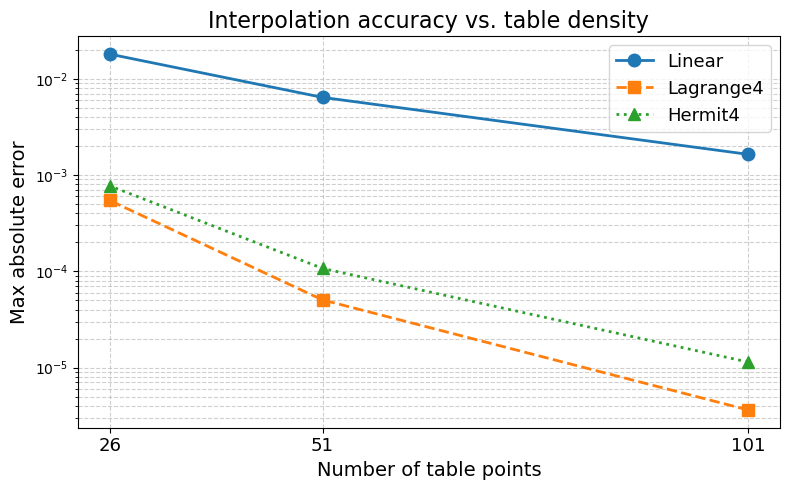


               Table        Linear     Lagrange4       Hermit4
--------------------------------------------------------------
      full (101 pts)    1.6411e-03    3.6267e-06    1.1404e-05
      half (~51 pts)    6.4126e-03    5.0458e-05    1.0719e-04
   quarter (~26 pts)    1.8049e-02    5.4442e-04    7.7296e-04


In [15]:
tables  = [(x,   y,   'full (101 pts)'),
           (xs2, ys2, 'half (~51 pts)'),
           (xs4, ys4, 'quarter (~26 pts)')]
methods = ['Linear', 'Lagrange4', 'Hermit4']

max_errors = np.zeros((len(tables), len(methods)))
table_sizes = []

for ti, (xt, yt, label) in enumerate(tables):
    table_sizes.append(len(xt))
    for mi, meth in enumerate(methods):
        yv = np.array([interp(xt, yt, x_test[k], meth) for k in range(ntests)])
        max_errors[ti, mi] = np.amax(np.abs(yv - np.cos(x_test)))

# Line plot: max error vs table size for each method
plt.figure(figsize=(8, 5))
styles  = ['o-', 's--', '^:']
colors  = ['tab:blue', 'tab:orange', 'tab:green']
for mi, meth in enumerate(methods):
    plt.plot(table_sizes, max_errors[:, mi],
             styles[mi], color=colors[mi],
             label=meth, linewidth=2, markersize=9)

plt.yscale('log')
plt.xlabel('Number of table points', fontsize=14)
plt.ylabel('Max absolute error', fontsize=14)
plt.title('Interpolation accuracy vs. table density', fontsize=16)
plt.xticks(table_sizes, [str(v) for v in table_sizes], fontsize=13)
plt.legend(fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Print summary table
print(f"\n{'Table':>20}  {'Linear':>12}  {'Lagrange4':>12}  {'Hermit4':>12}")
print("-" * 62)
for ti, (_, _, label) in enumerate(tables):
    print(f"{label:>20}  {max_errors[ti,0]:12.4e}  {max_errors[ti,1]:12.4e}  {max_errors[ti,2]:12.4e}")

<div dir="rtl">

---
## ניתוח

| שיטה | סדר שגיאה | גידול כשמכפילים $h$ |
|:---|:---:|:---:|
| ליניארית | $O(h^2)$ | $\times 4$ |
| לגראנז' 4 | $O(h^4)$ | $\times 16$ |
| הרמיט 4 | $O(h^4)$ | $\times 16$ |

- **ליניארית**: מתאימה ישר בין שני קשרים ומתעלמת מעקמומיות. שגיאת הקיטוע מסדר $O(h^2)$ — האיבר הראשון שמוזנח בפיתוח טיילור הוא $\frac{1}{2}f''(x)h^2$. כשמוכפל $h$ (פחות נקודות) השגיאה גדלה פי $4$.

- **לגראנז' 4**: מתאימה קובי דרך 4 קשרים. שגיאת הקיטוע מסדר $O(h^4)$ — האיבר הראשון שמוזנח מכיל $f^{(4)}(x)$. עם הכפלת $h$ השגיאה גדלה פי $16$.

- **הרמיט 4**: גם $O(h^4)$, אבל מוסיף התאמת נגזרות בנקודות הקצה — עקומה חלקה $C^1$. בפועל קבוע השגיאה קטן יותר מאשר בלגראנז', אז הדיוק לרוב דומה או טוב יותר.

**למה נוסחת 3 נקודות לנגזרת?**
הריווח לא אחיד, לכן הפרש מרכזי רגיל $(y_{i+1}-y_{i-1})/(2h)$ ייתן דיוק $O(h)$ בלבד (מניח ריווח שווה). נגזרת פולינום לגראנז' של 3 נקודות שומרת על $O(h^2)$ גם עם ריווח לא-אחיד.

בגרף הלוג: שיפוע כל שיטה = סדר השגיאה שלה.

</div>

<div dir="rtl">

---
## הערה: טיפול בגבולות

שיטות 4 הנקודות דורשות 2 קשרים משני הצדדים. קרוב לקצוות ($x_1 \le x[1]$ או $x_1 \ge x[n-2]$) מחזירים את ערך הטבלה הקרוב כדי לא לצאת מתחום.

</div>